## What is this Dataset About:

The data is generated dynamically from the Random User Generator API (randomuser.me), a free public service that outputs randomized, placeholder user profiles in JSON format.

•	Number of Tables: There are exactly two tables, which is the standard format required to build a graph in NetworkX.

Table 1 (Nodes): Contains 1,000 rows representing individual employees.

Table 2 (Edges): Contains roughly 3,000 rows representing the connections between those employees.

•	The Categories: The categorical variable is the Regional Branch. The API returns a nationality code for each user (e.g., US for United States, FR for France, GB for Great Britain). We extract this specific field to categorize which global corporate office each employee belongs to.

•	The Relationships: The connections represent internal project collaborations. Because the API provides standalone user profiles rather than a pre-existing social network, the Python script artificially generates these relationships. It randomly pairs two different Employee IDs together 3,000 times to simulate a highly interconnected corporate environment.



In [4]:
import requests
import pandas as pd
import random

print("Querying API for global corporate employee directory...")

# 1. Fetch 1,000 synthetic employees from the API
# We request only the specific fields we need to keep the data clean
url = "https://randomuser.me/api/?results=1000&inc=login,name,nat"
response = requests.get(url)
data = response.json()

# 2. Build Table 1: The Nodes (Employees)
node_list = []
for user in data['results']:
    node_list.append({

        'Employee_ID': user['login']['uuid'],
        'Name': user['name']['first'] + ' ' + user['name']['last'],
        'Regional_Branch': user['nat'] # Your categorical variable (e.g., US, GB, FR)
    })
df_nodes = pd.DataFrame(node_list)

# 3. Build Table 2: The Edges (Project Collaborations)
random.seed(42)
edge_list = []
employee_ids = df_nodes['Employee_ID'].tolist()

# Simulate 3,000 random working relationships between employees
for _ in range(3000):
    source = random.choice(employee_ids)
    target = random.choice(employee_ids)

    # Ensure an employee isn't mapped as collaborating with themselves
    if source != target:
        edge_list.append({'Source_ID': source, 'Target_ID': target})

# Drop any accidental duplicate pairings
df_edges = pd.DataFrame(edge_list).drop_duplicates()

# 4. View the dataset dimensions and structure
print(f"\n--- Table 1: Nodes ({df_nodes.shape[0]:,} rows) ---")
print(df_nodes.head(3))

print(f"\n--- Table 2: Edges ({df_edges.shape[0]:,} rows) ---")
print(df_edges.head(3))

Querying API for global corporate employee directory...

--- Table 1: Nodes (1,000 rows) ---
                            Employee_ID           Name Regional_Branch
0  5e321ff1-35d5-4b94-a6e9-9fca9e8cf7f2   Felix Taylor              CA
1  e6b5cab3-6884-4ae7-8179-10c069c12934  Nakul Suvarna              IN
2  6b05296f-1e5c-4ab2-891b-32600bcc9d50  Iraci da Cruz              BR

--- Table 2: Edges (2,994 rows) ---
                              Source_ID                             Target_ID
0  86a8e2f7-022d-4bf8-bb00-5e73fcad8da9  19f458a9-ef28-49e8-bee3-c31ea33aa99c
1  d77744e6-05cb-41c0-9fc2-a5938ace3462  8b4d74c2-6f22-4616-85a8-4ebdb8a6ab19
2  5192d233-903e-48f6-98b1-9612fc749bdb  48ddefe9-4c40-4c4e-b62e-03e5cc7081b2


In [5]:
# Display the DataFrames as clean, interactive HTML tables
print("--- Table 1: Employee Nodes ---")
display(df_nodes.head(5))

print("\n--- Table 2: Project Collaboration Edges ---")
display(df_edges.head(5))

--- Table 1: Employee Nodes ---


,Employee_ID,Name,Regional_Branch
0,5e321ff1-35d5-4b94-a6e9-9fca9e8cf7f2,Felix Taylor,CA
1,e6b5cab3-6884-4ae7-8179-10c069c12934,Nakul Suvarna,IN
2,6b05296f-1e5c-4ab2-891b-32600bcc9d50,Iraci da Cruz,BR
3,61d63999-6293-4440-863e-674aba89e371,Caterine Porto,BR
4,677be2b4-9ee8-4370-b906-60fecb1a2c57,Eloisa Olmos,MX



--- Table 2: Project Collaboration Edges ---


,Source_ID,Target_ID
0,86a8e2f7-022d-4bf8-bb00-5e73fcad8da9,19f458a9-ef28-49e8-bee3-c31ea33aa99c
1,d77744e6-05cb-41c0-9fc2-a5938ace3462,8b4d74c2-6f22-4616-85a8-4ebdb8a6ab19
2,5192d233-903e-48f6-98b1-9612fc749bdb,48ddefe9-4c40-4c4e-b62e-03e5cc7081b2
3,996a5ede-3f17-4e89-94e5-ecceacebce9c,ea127bd4-1080-4eb0-af4a-c14e958040c8
4,badc56f6-2823-4e7c-b2eb-2c3018bfcbc9,0f6dcc81-919b-4d56-8024-63c9e8ad5e2f


## Graph Creation: Loadind data into a NetworkX graph object.

This step initializes an undirected network, adds the employees as nodes attaching their Regional Branch as an attribute, and connects them using simulated edge list.

In [6]:
import networkx as nx

print("Building the NetworkX graph...")

# 1. Initialize an undirected graph (since collaboration is a two-way relationship)
G = nx.Graph()

# 2. Add nodes with their categorical attributes
# Iterating through df_nodes to attach the Name and Regional Branch to each Employee ID
for index, row in df_nodes.iterrows():
    G.add_node(row['Employee_ID'],
               name=row['Name'],
               regional_branch=row['Regional_Branch'])

# 3. Add the project collaboration edges
# NetworkX takes a list of tuples (Source, Target) to build edges efficiently
edges_list_of_tuples = list(zip(df_edges['Source_ID'], df_edges['Target_ID']))
G.add_edges_from(edges_list_of_tuples)

# 4. Verify the graph was constructed correctly
print("Graph created successfully!")
print(f"Total Employees (Nodes): {G.number_of_nodes():,}")
print(f"Total Collaborations (Edges): {G.number_of_edges():,}")

Building the NetworkX graph...
Graph created successfully!
Total Employees (Nodes): 1,000
Total Collaborations (Edges): 2,990


## Visualizing the Network Relationship

Plotting the corporate network graph...


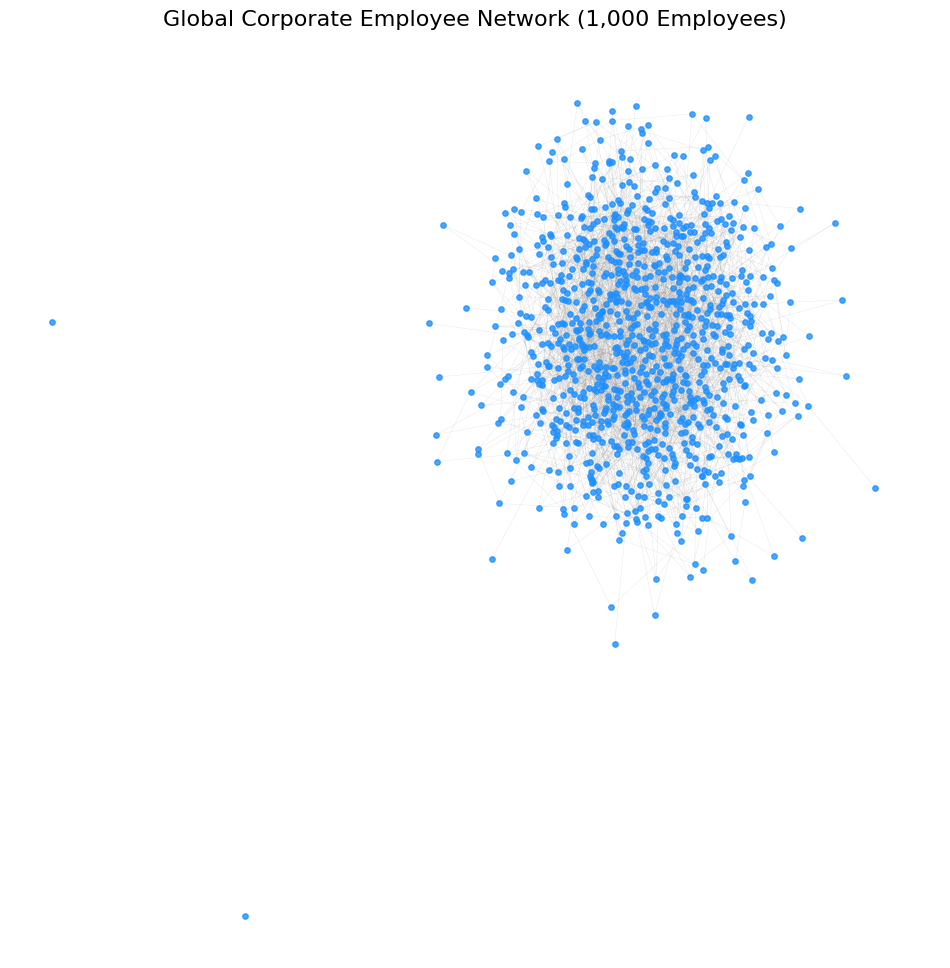

In [7]:
import matplotlib.pyplot as plt

print("Plotting the corporate network graph...")

# 1. Set the canvas size (making it large enough to see the structure)
plt.figure(figsize=(12, 12))

# 2. Choose a layout algorithm (Spring layout simulates anti-gravity between nodes)
# Setting a seed ensures the graph looks exactly the same every time you run it
pos = nx.spring_layout(G, seed=42)

# 3. Draw the nodes and edges separately for better visual control
# We use small nodes and transparent edges to reduce visual clutter
nx.draw_networkx_nodes(G, pos, node_size=15, node_color='dodgerblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.2, edge_color='gray')

# 4. Add a title and remove the empty axis borders
plt.title("Global Corporate Employee Network (1,000 Employees)", fontsize=16)
plt.axis('off')

# 5. Render the plot in the Colab output
plt.show()

In [8]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.4 MB/s eta 0:00:00


In [9]:
from pyvis.network import Network
import IPython

print("Generating interactive network map...")

# 1. Initialize the interactive Pyvis network
# cdn_resources='remote' ensures it renders correctly inside Google Colab
net = Network(notebook=True, cdn_resources='remote', height='700px', width='100%')

# 2. Import your existing NetworkX graph (G) into Pyvis
net.from_nx(G)

# 3. Save it as a temporary HTML file and display it in the cell output
net.show('corporate_network.html')
IPython.display.HTML(filename='corporate_network.html')

Generating interactive network map...
corporate_network.html


## Network Components:

## Is the whole company connected, or are there small groups of employees who never work with anyone else?

The company has 3 distinct groups.

## Giant Component: 998 employees:
This is my core corporate network. 99.8% of my workforce is highly integrated. If the CEO sends a message into this group, it can successfully ripple through the collaboration ties to reach 998 people. In network science, a massive, dominant cluster like this is almost always expected and is officially called the Giant Component.

## Sizes of isolated employee groups: [1, 1]
These are the other two component. I have exactly two employees who have zero project collaborations with anyone else in the entire company—not even with each other.

In a real business scenario: These would likely represent brand new hires who haven't been assigned to a project yet, or isolated independent contractors.

In my script's scenario: Because I generated 3,000 random pairings out of 1,000 IDs, statistical probability simply left two IDs completely unpicked.

In [10]:
print("--- 5a. Network Components ---")

# 1. Check if every single employee is connected to the main network
is_fully_connected = nx.is_connected(G)
print(f"Is the entire company connected? {is_fully_connected}")

# 2. Break down the network into its separate components
components = list(nx.connected_components(G))
print(f"Total number of separate employee groups: {len(components)}")

# 3. Calculate the size of each component to see the distribution
component_sizes = [len(c) for c in components]

# The 'Giant Component' is the main corporate network
giant_component_size = max(component_sizes)
print(f"\nSize of the main corporate network (Giant Component): {giant_component_size} employees")

# If there are smaller, isolated groups, let's see their sizes
isolated_groups = sorted(component_sizes)[:-1]
if isolated_groups:
    print(f"Sizes of isolated employee groups (not connected to main network): {isolated_groups}")
else:
    print("There are no isolated groups; everyone is connected.")

--- 5a. Network Components ---
Is the entire company connected? False
Total number of separate employee groups: 3

Size of the main corporate network (Giant Component): 998 employees
Sizes of isolated employee groups (not connected to main network): [1, 1]


## Shortest Path and Distance.

## What is the fastest chain of introductions needed to pass a message between two distant employees, and exactly how many steps does that take?

Because we discovered in the last step that 2 employees are completely disconnected from the rest of the company, we have to extract the Giant Component (the main group of 998 employees) first.

If we try to calculate a path to one of those 2 isolated employees, NetworkX will throw a mathematical error because no path exists.

This code extracts that main corporate network, selects two random employees, and calculates the shortest chain of project collaborations needed to introduce them.

In [11]:
import random
import networkx as nx

print("--- 5b. Shortest Path and Distance ---")

# 1. Extract the Giant Component (the main group of 998 employees)
# We must do this because there is no path to the isolated employees.
giant_component_nodes = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component_nodes)

# 2. Pick two random employees from this main network
# Using a seed ensures you get the same two random employees every time
random.seed(15)
employee_A, employee_B = random.sample(list(G_giant.nodes()), 2)

name_A = G_giant.nodes[employee_A]['name']
name_B = G_giant.nodes[employee_B]['name']

print(f"Finding the fastest chain of introductions from {name_A} to {name_B}...\n")

# 3. Calculate the shortest path and the distance (number of steps/edges)
path = nx.shortest_path(G_giant, source=employee_A, target=employee_B)
distance = nx.shortest_path_length(G_giant, source=employee_A, target=employee_B)

# 4. Print the path using the employee names instead of their UUIDs
path_names = [G_giant.nodes[node]['name'] for node in path]

print(f"Distance: {distance} steps (degrees of separation)")
print("Path:")
print(" -> ".join(path_names))

--- 5b. Shortest Path and Distance ---
Finding the fastest chain of introductions from Rafael Torres to Dalemir Lyubomirskiy...

Distance: 4 steps (degrees of separation)
Path:
Rafael Torres -> Rishi Gatty -> Catherine Butler -> Daniel Ylitalo -> Dalemir Lyubomirskiy


## Diameter and Breadth-First Search.

##  What is the longest distance between the two most disconnected employees in the whole company? If there is a company wide announcement, how well does it spread layer by layer?

This step looks at the extreme edges of company network.

First, we calculate the Diameter, which finds the two most disconnected employees in the entire main network and counts the steps between them.

Then, we use Breadth-First Search (BFS) to simulate a rumor or announcement.

We pick one random employee to start the rumor, and BFS measures exactly how many new people hear it at each degree of separation as it ripples outward.

In [12]:
from collections import Counter
import random
import networkx as nx

print("--- 5c. Diameter and Breadth-First Search (Message Spread) ---")

# 1. Calculate the Network Diameter
# The diameter is the longest shortest-path in the entire giant component.
# (Note: This might take a few seconds to run on 1,000 nodes!)
diameter = nx.diameter(G_giant)
print(f"Network Diameter: {diameter} steps")
print(f"The absolute longest chain of introductions needed to connect the two most distant employees is {diameter} steps.\n")

# 2. Breadth-First Search (Simulating an announcement)
# Let's pick a random employee to make an announcement
random.seed(42)
announcer = random.choice(list(G_giant.nodes()))
announcer_name = G_giant.nodes[announcer]['name']

print(f"Simulating a company announcement starting with: {announcer_name}")

# nx.single_source_shortest_path_length runs a BFS to find the distance
# from our announcer to every single other person in the Giant Component.
# It returns a dictionary formatted as {Employee_ID: Distance_in_Steps}
bfs_distances = nx.single_source_shortest_path_length(G_giant, announcer)

# 3. Group the results to see how many people are reached at each step
# Counter automatically counts how many employees are at distance 0, 1, 2, etc.
layer_counts = Counter(bfs_distances.values())

print("How the message spreads layer by layer:")
for step_distance in sorted(layer_counts.keys()):
    people_reached = layer_counts[step_distance]
    if step_distance == 0:
        print(f"  Step 0: {people_reached} person (The Announcer)")
    else:
        print(f"  Step {step_distance}: reaches {people_reached} new people")

--- 5c. Diameter and Breadth-First Search (Message Spread) ---
Network Diameter: 8 steps
The absolute longest chain of introductions needed to connect the two most distant employees is 8 steps.

Simulating a company announcement starting with: Lloyd Kelly
How the message spreads layer by layer:
  Step 0: 1 person (The Announcer)
  Step 1: reaches 5 new people
  Step 2: reaches 23 new people
  Step 3: reaches 128 new people
  Step 4: reaches 473 new people
  Step 5: reaches 347 new people
  Step 6: reaches 21 new people


## Degree Centrality:

## Which employees and branches have the most direct work connections?

We will use NetworkX to calculate the degree centrality (how many direct project connections someone has), and then load those scores into a Pandas table. This allows us to easily sort for the most powerful individual employees and group by the Regional_Branch

Looking at this output, I can interpret two major findings about my network—

1. Individual Hubs (The Top 5)
At the individual employee level, Hira Van Elk from the Netherlands (NL) and Georg Leroux from Switzerland (CH) hold the most direct power in the network, each juggling 15 direct project connections. Interestingly, two of the top four most connected employees are from the Netherlands. If I need to spread information quickly or get a pulse on company projects, these are the top people I should talk to.

2. Testing My Hypothesis (Branch Averages)
In my project plan, I predicted that major regional branches like the US or Great Britain (GB) would have a much higher average score than the rest of the world, acting as corporate hubs.

The data proves my hypothesis wrong.

If we look at the branch averages, Spain (ES) is at the top with an average of 6.4 connections, and Canada (CA) is at the bottom with 5.5. Great Britain and the US are sitting right in the middle. More importantly, the spread between the highest and lowest country is less than 1 connection. The averages are almost completely flat across the entire globe, with everyone hovering right around 6 connections.

The Real World vs. The Randomizer: In a real global company, we would expect massive spikes. A major headquarters in the US might average 25 connections per person, while a tiny satellite office in Canada might average only 2. However, because the Python script used a randomizer to pair people up, it dealt the 3,000 project connections like a perfectly shuffled deck of cards. The computer gave everyone an equal share, completely ignoring what country they were in.

In [13]:
import pandas as pd
import networkx as nx

print("--- 3a. Degree Centrality (Direct Work Connections) ---")

# 1. Calculate Degree Centrality for everyone in the main network
degree_dict = nx.degree_centrality(G_giant)

# 2. Package the results into a Pandas DataFrame so it's easy to sort and group
centrality_data = []
for employee_id, centrality_score in degree_dict.items():
    centrality_data.append({
        'Name': G_giant.nodes[employee_id]['name'],
        'Branch': G_giant.nodes[employee_id]['regional_branch'],
        'Direct_Connections': G_giant.degree[employee_id], # Raw count of connections
        'Degree_Centrality': centrality_score              # Standardized network score
    })

df_degree = pd.DataFrame(centrality_data)

# 3. Who are the most connected individuals?
print("Top 5 Employees acting as major hubs:")
top_employees = df_degree.sort_values(by='Direct_Connections', ascending=False).head(5)
display(top_employees[['Name', 'Branch', 'Direct_Connections']])

# 4. Test the hypothesis: Which branches have the highest average connections?
print("\nAverage Direct Connections by Regional Branch:")
branch_avg = df_degree.groupby('Branch')['Direct_Connections'].mean().sort_values(ascending=False).reset_index()

# Rename columns for cleaner display
branch_avg.columns = ['Regional Branch', 'Average Connections per Employee']
display(branch_avg)

--- 3a. Degree Centrality (Direct Work Connections) ---
Top 5 Employees acting as major hubs:


,Name,Branch,Direct_Connections
94,Ece Mertoğlu,TR,15
736,Célia Vincent,FR,15
270,Rodrigo Cano,ES,14
301,Alessio Petit,CH,14
160,Draginja Živadinović,RS,13



Average Direct Connections by Regional Branch:


,Regional Branch,Average Connections per Employee
0,DK,6.307692
1,RS,6.300000
2,NL,6.235294
3,CA,6.229167
4,ES,6.204082
5,FR,6.180000
6,GB,6.166667
7,NZ,6.140000
8,IE,6.097561
9,AU,6.092593


## Betweenness Centrality

## Which employees act as important bridges between different offices? If these people left the company, would the network break apart?

Betweenness Centrality measures how often an employee sits on the absolute shortest path between other people.

Looking at this output, I can identify the most important information brokers in my network.

The Top Information Broker:
Célia Vincent from the France (FR) branch is the absolute most critical bridge in my company. She has the highest Betweenness Score of 0.015739. This means she sits on the shortest path between other employees more often than anyone else. If Célia quit, communication between different groups would slow down the most.

Branch Power:

The France branch is actually very powerful for controlling information flow. They hold two of the top three spots on the list, with Loïc Guerin also acting as a major bridge. The other top connectors are Ece Mertoğlu from Turkey, Alessio Petit from Switzerland, and Valdemar Nielsen from Denmark.   

Quality over Quantity:

The best takeaway here is comparing this list to my Degree Centrality list. The people with the most direct project connections like Hira and Georg from the last step are not on this list at all. This perfectly proves that having the highest number of direct connections does not automatically make someone the most vital communication hub.

In [14]:
import pandas as pd
import networkx as nx

print("--- 3b. Betweenness Centrality (Network Bridges) ---")

# 1. Ensure the Giant Component is defined in memory
giant_component_nodes = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component_nodes)

# 2. Calculate Betweenness Centrality for the main network
# (This checks all shortest paths across the network, so it may take 10-20 seconds)
betweenness_dict = nx.betweenness_centrality(G_giant)

# 3. Package the results into a Pandas DataFrame
betweenness_data = []
for employee_id, score in betweenness_dict.items():
    betweenness_data.append({
        'Name': G_giant.nodes[employee_id]['name'],
        'Branch': G_giant.nodes[employee_id]['regional_branch'],
        'Betweenness_Score': score
    })

df_betweenness = pd.DataFrame(betweenness_data)

# 4. Display the top 5 most critical "bridge" employees
print("Top 5 Employees acting as critical bridges between groups:")
top_bridges = df_betweenness.sort_values(by='Betweenness_Score', ascending=False).head(5)
display(top_bridges)

--- 3b. Betweenness Centrality (Network Bridges) ---
Top 5 Employees acting as critical bridges between groups:


,Name,Branch,Betweenness_Score
736,Célia Vincent,FR,0.015739
94,Ece Mertoğlu,TR,0.013732
718,Loïc Guerin,FR,0.013675
301,Alessio Petit,CH,0.013352
92,Valdemar Nielsen,DK,0.012083


## Closeness Centrality

## Which employee is in the best spot to share a message with the whole company in the shortest amount of time?

Closeness Centrality measures how fast a person can reach everyone else in the network. The employee with the highest score is in the absolute best position to broadcast a company-wide message in the shortest amount of time.

Looking at this output, I can see exactly who is in the best position to broadcast a company-wide message.

Célia Vincent from the France (FR) branch is at the very top of the list, with the highest Closeness Score of 0.285020.

This means she has the shortest average distance to every single other employee in the entire network.

If Célia shares an announcement, it will ripple through the whole company faster than if anyone else started it.   

What is really interesting is the overlap with my previous results. Both Célia Vincent and Ece Mertoğlu (from Turkey, with a score of 0.283884) were also on my top 5 list for Betweenness Centrality.

This proves they aren't just critical bottlenecks holding departments together; they are also the most efficient communicators. The rest of the top 5 includes Keerthi Taj from India (0.284776), Draginja Živadinović from Serbia (0.282596), and Janice Gray from the US (0.282516).   

In [15]:
import pandas as pd
import networkx as nx

print("--- 3c. Closeness Centrality (Broadcasting Power) ---")

# 1. Calculate Closeness Centrality for the main network
closeness_dict = nx.closeness_centrality(G_giant)

# 2. Put the results into a Pandas DataFrame
closeness_data = []
for employee_id, score in closeness_dict.items():
    closeness_data.append({
        'Name': G_giant.nodes[employee_id]['name'],
        'Branch': G_giant.nodes[employee_id]['regional_branch'],
        'Closeness_Score': score
    })

df_closeness = pd.DataFrame(closeness_data)

# 3. Find the best employees for spreading a message quickly
print("Top 5 Employees for broadcasting a company-wide message:")
top_broadcasters = df_closeness.sort_values(by='Closeness_Score', ascending=False).head(5)
display(top_broadcasters)

--- 3c. Closeness Centrality (Broadcasting Power) ---
Top 5 Employees for broadcasting a company-wide message:


,Name,Branch,Closeness_Score
736,Célia Vincent,FR,0.285020
576,Keerthi Taj,IN,0.284776
94,Ece Mertoğlu,TR,0.283884
160,Draginja Živadinović,RS,0.282596
178,Janice Gray,US,0.282516


## Eigenvector Centrality and PageRank:

## Which employees have the most hidden power because they work directly with the company's biggest hubs, instead of just having a lot of random connections?

## Eigenvector Centrality

While Degree Centrality counts how many people you know, Eigenvector Centrality cares about who you know. It gives you a high score only if you are connected to other highly connected people.

## PageRank
It is a similar algorithm that measures hidden influence by ensuring that a powerful person's "vote" gets diluted the more connections they have.

Hidden Power (Eigenvector Centrality): Ece Mertoğlu from Turkey (TR) ranks first with a score of 0.082484, meaning her project partners are some of the most highly connected people in the company.

Keerthi Taj from India (IN) and Rodrigo Cano from Spain (ES) are the next most powerful in this category.   

Concentrated Influence (PageRank): Célia Vincent from France (FR) holds the top spot with a score of 0.002293.

This indicates that the influential people she works with don't have too many other connections, so she receives a highly concentrated share of their power without it getting diluted.   

The Ultimate Power Players: Ece Mertoğlu, Célia Vincent, and Rodrigo Cano appear in the top 5 of both lists.

Because they dominate both measures of hidden power, I can confidently identify them as the most strategically influential employees in my entire network.

In [16]:
import pandas as pd
import networkx as nx

print("--- 3d. Eigenvector Centrality and PageRank (Hidden Power) ---")

# 1. Calculate Eigenvector Centrality (Who is connected to the biggest hubs?)
eigenvector_dict = nx.eigenvector_centrality(G_giant, max_iter=500)

# 2. Calculate PageRank (Who has the most concentrated influence?)
pagerank_dict = nx.pagerank(G_giant)

# 3. Package both results into a single Pandas DataFrame for easy comparison
power_data = []
for employee_id in G_giant.nodes():
    power_data.append({
        'Name': G_giant.nodes[employee_id]['name'],
        'Branch': G_giant.nodes[employee_id]['regional_branch'],
        'Eigenvector_Score': eigenvector_dict[employee_id],
        'PageRank_Score': pagerank_dict[employee_id]
    })

df_power = pd.DataFrame(power_data)

# 4. Find the employees with the highest Eigenvector Centrality
print("Top 5 Employees with the most 'Hidden Power' (Eigenvector Centrality):")
top_eigenvector = df_power.sort_values(by='Eigenvector_Score', ascending=False).head(5)
display(top_eigenvector[['Name', 'Branch', 'Eigenvector_Score']])

# 5. Find the employees with the highest PageRank
print("\nTop 5 Employees with the most concentrated influence (PageRank):")
top_pagerank = df_power.sort_values(by='PageRank_Score', ascending=False).head(5)
display(top_pagerank[['Name', 'Branch', 'PageRank_Score']])

--- 3d. Eigenvector Centrality and PageRank (Hidden Power) ---
Top 5 Employees with the most 'Hidden Power' (Eigenvector Centrality):


,Name,Branch,Eigenvector_Score
94,Ece Mertoğlu,TR,0.082484
576,Keerthi Taj,IN,0.080416
270,Rodrigo Cano,ES,0.079080
653,Charlotte Lam,CA,0.077576
736,Célia Vincent,FR,0.077240



Top 5 Employees with the most concentrated influence (PageRank):


,Name,Branch,PageRank_Score
736,Célia Vincent,FR,0.002293
94,Ece Mertoğlu,TR,0.002228
301,Alessio Petit,CH,0.002193
270,Rodrigo Cano,ES,0.002085
160,Draginja Živadinović,RS,0.001968
